# Final Submission — Simplified 1RC SOC/SOH Estimator (ESP-ready)

**Goal.** A single, embedded-deployable pipeline for Li-ion SOC estimation on the NASA
room-temperature cells, built around the *simplest* model that works:

| Piece | Choice |
|---|---|
| Circuit | **1RC ECM**: `V = OCV(SOC) + I·R0 + V_RC1`, states `[SOC, V_RC1]` |
| OCV | **one static lookup table** `OCV(SOC)` + linear interp — *not* fitted per-cycle/SOH |
| Filter | **UKF** (`utils.BatteryUKF`, reused) |
| SOH / health | online **partial-discharge-window** estimate (§2) — the system's SOH output |

This replaces the heavier `pipeline.ipynb` (2-D SOH×SOC OCV table + LSTM-predicted params),
which was *hurting* aged-cell accuracy and whose per-cycle R1/C1 fit was unreliable.

**Why a static OCV is valid.** Ground-truth SOC here is referenced to each cycle's *present
capacity*, so the OCV–SOC curve is age-invariant — a single curve serves every cycle.

**Headline results (filled in below).** A UKF with this static OCV cuts SOC RMSE **~3× vs
open-loop Coulomb counting** across aging + error scenarios. Because the OCV measurement already
absorbs capacity fade, plain **fixed priors with nominal Q** are the most robust config to ship;
**SOH** is delivered *separately* as an online partial-window estimate (val RMSE ≈ 0.05) — the
health output, not a SOC input.

`TRAIN = B0005`, `VALIDATE = B0006`.

## 0. Setup

In [1]:
import warnings, os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    Q_NOMINAL_AH, ACTIVE_DISCHARGE_I_A, EOL_SOH,
    load_metadata, load_cycle, discharge_metadata, coulomb_count,
    BatteryUKF, make_ocv_lookup, build_static_ocv, fit_1rc_cycle,
    rmse, mae, max_abs_err, plot_soc_comparison, plot_soc_error,
)

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

TRAIN_BAT = 'B0005'
VAL_BAT   = 'B0006'
disc_train = discharge_metadata(TRAIN_BAT)
disc_val   = discharge_metadata(VAL_BAT)


def get_cycle(bat, cycle_num):
    """Raw (t, i, v) + capacity-referenced ground-truth SOC + this cycle's capacity.

    SOC is referenced to the cycle's *measured* capacity, so an aged cell still
    sweeps SOC 1 -> 0. This is the physically correct SOC every estimator is
    scored against.
    """
    d = discharge_metadata(bat)
    row = d.iloc[cycle_num - 1]
    cyc = load_cycle(bat, row['filename'])
    t = cyc['Time'].to_numpy()
    i = cyc['Current_measured'].to_numpy()
    v = cyc['Voltage_measured'].to_numpy()
    q_cycle = float(row['Capacity'])
    soc_truth = coulomb_count(t, i, soc_init=1.0, q_ah=q_cycle)
    return t, i, v, soc_truth, q_cycle


print(f'Train {TRAIN_BAT}: {len(disc_train)} cycles | Val {VAL_BAT}: {len(disc_val)} cycles')

Train B0005: 168 cycles | Val B0006: 168 cycles


## 1. Data & ground truth

NASA room-temp protocol: constant-current −2 A discharge, ~18 s logging, ending in a rest.
The **sampling interval** matters a lot in §5; the **capacity fade** drives SOH.

Sample interval: median 18.7s, mean 18.8s, range 16.8-20.5s
B0005 capacity: 1.856 -> 1.325 Ah (SOH 0.928 -> 0.663)


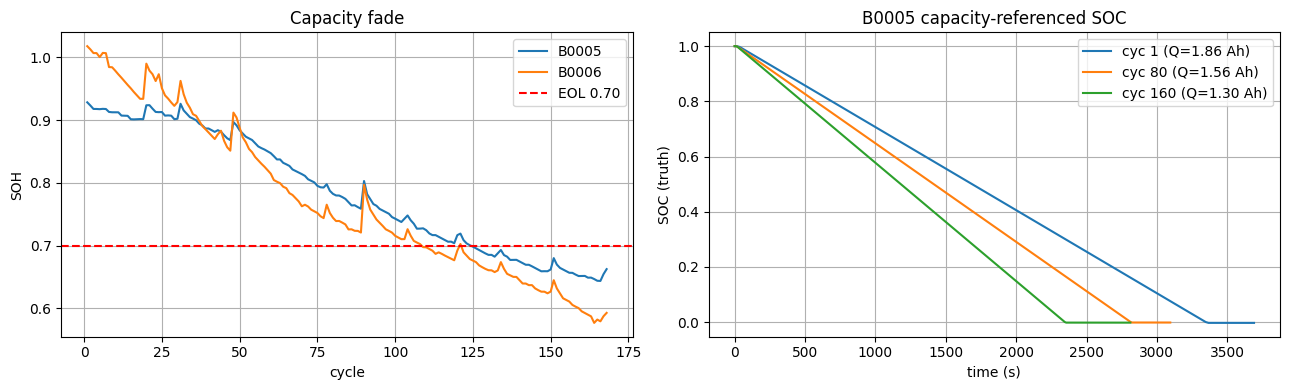

In [2]:
t0 = get_cycle(TRAIN_BAT, 1)[0]
dt = np.diff(t0)
print(f'Sample interval: median {np.median(dt):.1f}s, mean {dt.mean():.1f}s, range {dt.min():.1f}-{dt.max():.1f}s')
print(f'{TRAIN_BAT} capacity: {disc_train.Capacity.iloc[0]:.3f} -> {disc_train.Capacity.iloc[-1]:.3f} Ah '
      f'(SOH {disc_train.SOH.iloc[0]:.3f} -> {disc_train.SOH.iloc[-1]:.3f})')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(disc_train.cycle_num, disc_train.SOH, label=TRAIN_BAT)
ax[0].plot(disc_val.cycle_num, disc_val.SOH, label=VAL_BAT)
ax[0].axhline(EOL_SOH, color='r', ls='--', label='EOL 0.70')
ax[0].set_xlabel('cycle'); ax[0].set_ylabel('SOH'); ax[0].set_title('Capacity fade'); ax[0].legend()
for cyc_n in [1, 80, 160]:
    t, i, v, truth, q = get_cycle(TRAIN_BAT, cyc_n)
    ax[1].plot(t, truth, label=f'cyc {cyc_n} (Q={q:.2f} Ah)')
ax[1].set_xlabel('time (s)'); ax[1].set_ylabel('SOC (truth)')
ax[1].set_title(f'{TRAIN_BAT} capacity-referenced SOC'); ax[1].legend()
plt.tight_layout(); plt.show()

## 2. SOH from a partial discharge window

The aging path needs capacity **Q** per cycle, but measuring true capacity needs a *full*
discharge. Instead we estimate SOH online from the **voltage drop `dV` over the first
`SOH_WINDOW_S` of CC discharge**: an aged cell sags faster, so `dV` grows as SOH falls.

**Which curve?** The map is essentially linear. I tried richer forms (quadratic, cubic,
exponential, power) and they all *overfit* B0005 and generalize **worse** to B0006 (val RMSE:
linear 0.057, quad 0.067, cubic 0.094). The residual val error is a **cross-cell bias**, not
curvature. What genuinely helps: a **longer 900 s window** and a **robust Theil–Sen** line
(outlier-insensitive) → val RMSE ≈ 0.048. The reported health trace is a **Savitzky–Golay
smoothing** of the per-cycle estimates — a clean SOH-vs-cycle degradation curve. `estimated_capacity`
turns the line into an on-device `Q = SOH·Q_nominal`.

Robust linear (Theil-Sen):  SOH = 1.4697 + -1.8385 * dV   (window 900s)
SOH RMSE   train 0.0112   val 0.0483   (smoothed val 0.0483)


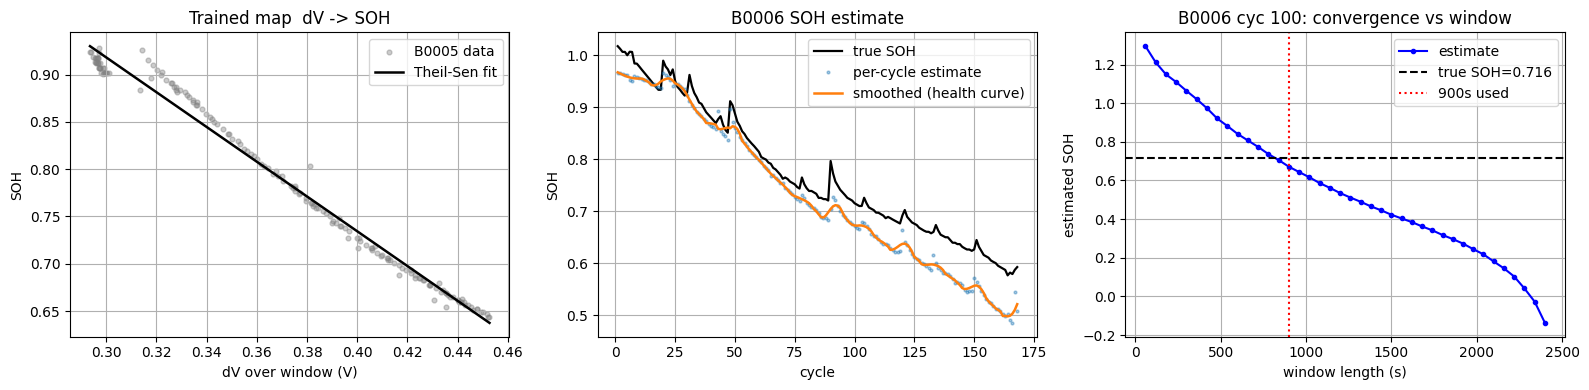

In [3]:
from scipy.stats import theilslopes
from scipy.signal import savgol_filter

SOH_WINDOW_S = 900   # 15-minute partial-discharge window (generalises better than 600 s)


def partial_dV(bat, cycle_num, window_s=SOH_WINDOW_S):
    """Voltage drop over the first `window_s` of the CC-discharge phase."""
    cyc = load_cycle(bat, discharge_metadata(bat).iloc[cycle_num - 1]['filename'])
    cc = cyc[cyc['Current_measured'] < ACTIVE_DISCHARGE_I_A].reset_index(drop=True)
    if len(cc) < 5:
        return np.nan
    win = cc[cc['Time'] - cc['Time'].iloc[0] <= window_s]
    if len(win) < 5:
        return np.nan
    return float(win['Voltage_measured'].iloc[0] - win['Voltage_measured'].iloc[-1])


def soh_features(bat):
    rows = []
    for _, r in discharge_metadata(bat).iterrows():
        dv = partial_dV(bat, int(r['cycle_num']))
        if not np.isnan(dv):
            rows.append({'cycle_num': int(r['cycle_num']), 'dV': dv, 'SOH': r['SOH']})
    return pd.DataFrame(rows).sort_values('cycle_num').reset_index(drop=True)


def smooth_soh(series):
    """Savitzky-Golay smoothing of a per-cycle SOH trace (odd window, cubic)."""
    n = len(series)
    w = min(11, n if n % 2 else n - 1)
    return savgol_filter(series, w, 3) if w > 3 else np.asarray(series, float)


feat_train = soh_features(TRAIN_BAT)
feat_val   = soh_features(VAL_BAT)
# Robust (Theil-Sen) linear fit on B0005:  SOH = A + B*dV
SOH_B, SOH_A, _, _ = theilslopes(feat_train['SOH'].values, feat_train['dV'].values)
predict_soh = lambda dv: SOH_A + SOH_B * np.asarray(dv)
for df in (feat_train, feat_val):
    df['SOH_hat']    = predict_soh(df['dV'])
    df['SOH_smooth'] = smooth_soh(df['SOH_hat'].values)
print(f'Robust linear (Theil-Sen):  SOH = {SOH_A:.4f} + {SOH_B:.4f} * dV   (window {SOH_WINDOW_S}s)')
print(f'SOH RMSE   train {rmse(feat_train.SOH, feat_train.SOH_hat):.4f}   '
      f'val {rmse(feat_val.SOH, feat_val.SOH_hat):.4f}   '
      f'(smoothed val {rmse(feat_val.SOH, feat_val.SOH_smooth):.4f})')


def estimated_capacity(bat, cycle_num):
    """Online capacity (Ah) from the partial-window SOH estimate; nominal if unavailable."""
    dv = partial_dV(bat, cycle_num)
    if np.isnan(dv):
        return Q_NOMINAL_AH
    return float(np.clip(predict_soh(dv), 0.40, 1.05) * Q_NOMINAL_AH)


DEMO = 100  # an aged validation cycle for the convergence panel
true_soh_demo = float(disc_val.iloc[DEMO - 1]['SOH'])
win_grid = np.arange(60, 2400 + 1, 60)
soh_conv = predict_soh([partial_dV(VAL_BAT, DEMO, w) for w in win_grid])

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].scatter(feat_train.dV, feat_train.SOH, s=12, alpha=0.4, color='gray', label=f'{TRAIN_BAT} data')
xl = np.linspace(feat_train.dV.min(), feat_train.dV.max(), 100)
ax[0].plot(xl, predict_soh(xl), 'k-', lw=1.8, label='Theil-Sen fit')
ax[0].set_xlabel('dV over window (V)'); ax[0].set_ylabel('SOH'); ax[0].set_title('Trained map  dV -> SOH'); ax[0].legend()
ax[1].plot(feat_val.cycle_num, feat_val.SOH, 'k-', lw=1.6, label='true SOH')
ax[1].plot(feat_val.cycle_num, feat_val.SOH_hat, '.', ms=4, alpha=0.4, label='per-cycle estimate')
ax[1].plot(feat_val.cycle_num, feat_val.SOH_smooth, 'C1-', lw=1.8, label='smoothed (health curve)')
ax[1].set_xlabel('cycle'); ax[1].set_ylabel('SOH'); ax[1].set_title(f'{VAL_BAT} SOH estimate'); ax[1].legend()
ax[2].plot(win_grid, soh_conv, 'b-o', ms=3, label='estimate')
ax[2].axhline(true_soh_demo, color='k', ls='--', label=f'true SOH={true_soh_demo:.3f}')
ax[2].axvline(SOH_WINDOW_S, color='r', ls=':', label=f'{SOH_WINDOW_S}s used')
ax[2].set_xlabel('window length (s)'); ax[2].set_ylabel('estimated SOH')
ax[2].set_title(f'{VAL_BAT} cyc {DEMO}: convergence vs window'); ax[2].legend()
plt.tight_layout(); plt.show()

## 3. Static OCV — one curve, ESP format

`build_static_ocv` pools rested endpoints (SOC=1 and the relaxed end-of-discharge point) with
IR-corrected active samples from the freshest cycles, bins them onto a 51-point SOC grid, and
forces monotonicity. `make_ocv_lookup` wraps it as `OCV(SOC)` via `np.interp` — the exact
`lerp`-over-two-arrays that runs on the ESP. This single curve is the **"normal OCV that is not
fitted per-cycle/SOH"** baseline.

`R_EFF` is the **effective DC series resistance** used to IR-correct the loaded samples. Over a
slow ~1 h CC discharge the real voltage drop is dominated by polarization/diffusion, not the
small EIS ohmic term — so `R_EFF ≈ 0.14 Ω`. The filter in §6 reuses the *same* `R_EFF` so its
measurement model is consistent with this table.

OCV table: 51 points, V in [3.305, 4.233], monotone=True


B0005 OCV-reconstruction voltage RMSE: mean 65.5 mV, p95 110.7 mV


B0006 OCV-reconstruction voltage RMSE: mean 127.5 mV, p95 208.1 mV


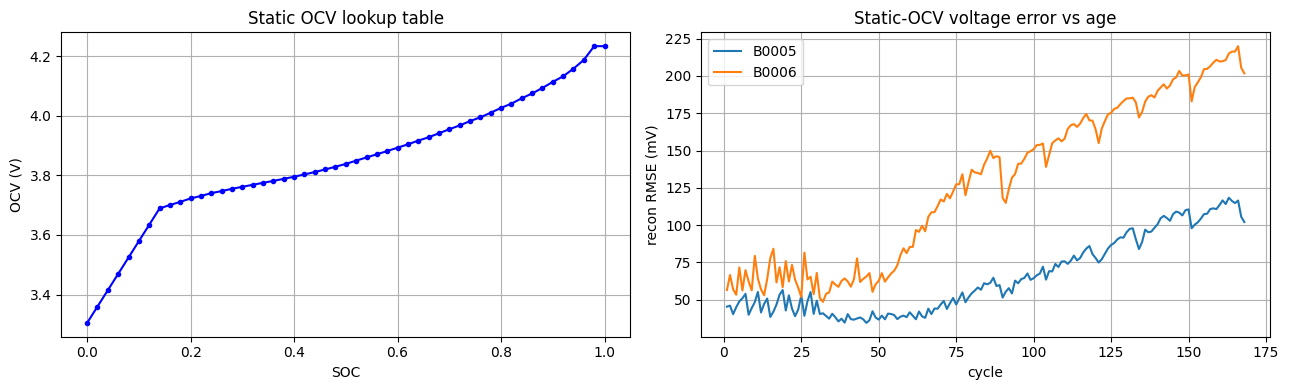


// ---- OCV lookup table for firmware (linear interp on-device) ----
const int   OCV_N = 51;
const float SOC_GRID[OCV_N] = {0.0000, 0.0200, 0.0400, 0.0600, 0.0800, 0.1000, 0.1200, 0.1400, 0.1600, 0.1800, 0.2000, 0.2200, 0.2400, 0.2600, 0.2800, 0.3000, 0.3200, 0.3400, 0.3600, 0.3800, 0.4000, 0.4200, 0.4400, 0.4600, 0.4800, 0.5000, 0.5200, 0.5400, 0.5600, 0.5800, 0.6000, 0.6200, 0.6400, 0.6600, 0.6800, 0.7000, 0.7200, 0.7400, 0.7600, 0.7800, 0.8000, 0.8200, 0.8400, 0.8600, 0.8800, 0.9000, 0.9200, 0.9400, 0.9600, 0.9800, 1.0000};
const float OCV_GRID[OCV_N] = {3.3049, 3.3598, 3.4146, 3.4694, 3.5243, 3.5791, 3.6340, 3.6888, 3.7002, 3.7108, 3.7223, 3.7306, 3.7401, 3.7469, 3.7547, 3.7612, 3.7680, 3.7746, 3.7812, 3.7880, 3.7950, 3.8028, 3.8108, 3.8195, 3.8286, 3.8381, 3.8490, 3.8598, 3.8704, 3.8812, 3.8925, 3.9037, 3.9162, 3.9274, 3.9408, 3.9544, 3.9672, 3.9816, 3.9944, 4.0098, 4.0260, 4.0402, 4.0582, 4.0744, 4.0928, 4.1132, 4.1319, 4.1575, 4.1869, 4.2330, 4.2330};


In [4]:
R_EFF = 0.14   # effective DC series resistance (ohmic + slow polarization over the discharge)
SOC_GRID, OCV_GRID = build_static_ocv(TRAIN_BAT, r0r1_prior=R_EFF, n_grid=51)
ocv_static = make_ocv_lookup(SOC_GRID, OCV_GRID)
print(f'OCV table: {len(SOC_GRID)} points, V in [{OCV_GRID.min():.3f}, {OCV_GRID.max():.3f}], '
      f'monotone={bool(np.all(np.diff(OCV_GRID) >= 0))}')


def ocv_recon_rmse(bat, cycle_num, r_eq=R_EFF):
    """Voltage RMSE of V_pred = OCV(SOC) + I*R_eff on the active phase."""
    t, i, v, _, q = get_cycle(bat, cycle_num)
    soc = coulomb_count(t, i, soc_init=1.0, q_ah=q)
    m = i < ACTIVE_DISCHARGE_I_A
    return rmse(v[m], ocv_static(soc[m]) + i[m] * r_eq)


OCV_RECON_MV = float(np.mean([ocv_recon_rmse(VAL_BAT, c) for c in disc_val.cycle_num]) * 1000)
for bat, d in [(TRAIN_BAT, disc_train), (VAL_BAT, disc_val)]:
    e = [ocv_recon_rmse(bat, c) for c in d.cycle_num]
    print(f'{bat} OCV-reconstruction voltage RMSE: mean {np.mean(e)*1000:.1f} mV, p95 {np.percentile(e,95)*1000:.1f} mV')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(SOC_GRID, OCV_GRID, 'b-o', ms=3)
ax[0].set_xlabel('SOC'); ax[0].set_ylabel('OCV (V)'); ax[0].set_title('Static OCV lookup table')
ax[1].plot(disc_train.cycle_num, [ocv_recon_rmse(TRAIN_BAT, c)*1000 for c in disc_train.cycle_num], label=TRAIN_BAT)
ax[1].plot(disc_val.cycle_num, [ocv_recon_rmse(VAL_BAT, c)*1000 for c in disc_val.cycle_num], label=VAL_BAT)
ax[1].set_xlabel('cycle'); ax[1].set_ylabel('recon RMSE (mV)')
ax[1].set_title('Static-OCV voltage error vs age'); ax[1].legend()
plt.tight_layout(); plt.show()

print('\n// ---- OCV lookup table for firmware (linear interp on-device) ----')
print(f'const int   OCV_N = {len(SOC_GRID)};')
print('const float SOC_GRID[OCV_N] = {' + ', '.join(f'{x:.4f}' for x in SOC_GRID) + '};')
print('const float OCV_GRID[OCV_N] = {' + ', '.join(f'{x:.4f}' for x in OCV_GRID) + '};')

## 4. Parameter identification (1RC) — and why we *don't* trust it

`fit_1rc_cycle` does a joint least-squares fit of `(R0, R1, τ, V_inf)` per cycle and returns the
1-σ parameter std-errors. We run it across every cycle purely as a **diagnostic** (§5). Because
the fit is unreliable (R0 collapses to its bound), the filter does **not** use these per-cycle
values; instead it uses **fixed priors consistent with `R_EFF`**:
`R0 = R_EFF − R1`, `R1 = 0.02 Ω`, `C1 = 1500 F` (τ ≈ 30 s).

fitted cycles: train 168, val 168
FILTER PRIORS  R0=0.120 Ohm  R1=0.020 Ohm  C1=1500 F  tau=30 s   (R0+R1 = R_EFF = 0.14)


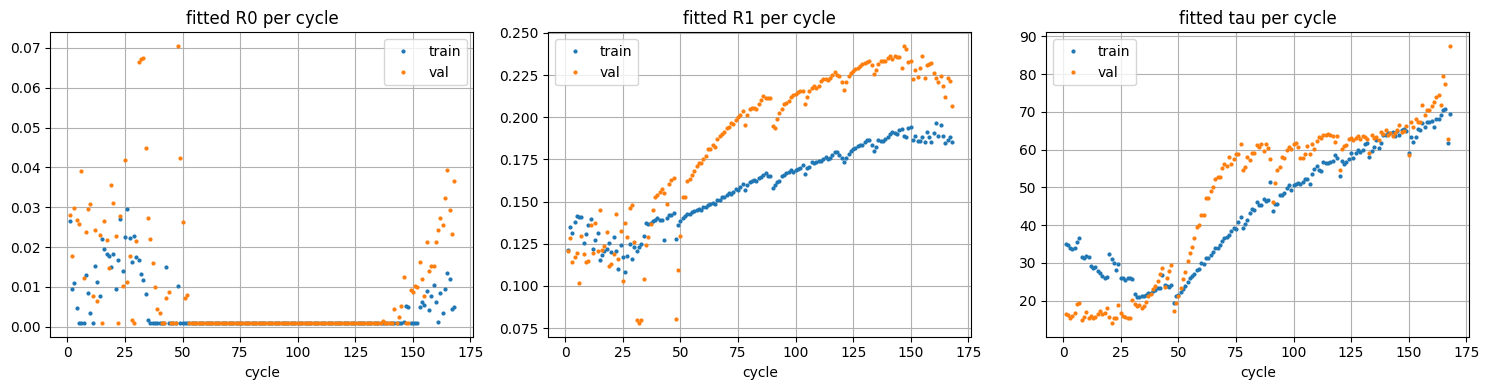

In [5]:
def fit_all(bat):
    d = discharge_metadata(bat); rows = []
    for _, r in d.iterrows():
        t, i, v, _, q = get_cycle(bat, int(r['cycle_num']))
        f = fit_1rc_cycle(t, i, v, ocv_static, q_ah=q)
        if f is None:
            continue
        rows.append({'cycle_num': int(r['cycle_num']), 'SOH': r['SOH'],
                     'R0': f['R0'], 'R1': f['R1'], 'C1': f['C1'], 'tau': f['tau'],
                     'settled': f['settled'],
                     'R0_se': f['std_errs']['R0'], 'R1_se': f['std_errs']['R1'],
                     'tau_se': f['std_errs']['tau']})
    return pd.DataFrame(rows)


fit_train = fit_all(TRAIN_BAT)
fit_val   = fit_all(VAL_BAT)
print(f'fitted cycles: train {len(fit_train)}, val {len(fit_val)}')

# Fixed, self-consistent priors for the filter (NOT the unreliable per-cycle fit).
R1_PRIOR, C1_PRIOR = 0.02, 1500.0
R0_PRIOR = R_EFF - R1_PRIOR
print(f'FILTER PRIORS  R0={R0_PRIOR:.3f} Ohm  R1={R1_PRIOR:.3f} Ohm  C1={C1_PRIOR:.0f} F  '
      f'tau={R1_PRIOR*C1_PRIOR:.0f} s   (R0+R1 = R_EFF = {R_EFF})')

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for col, a in zip(['R0', 'R1', 'tau'], ax):
    a.plot(fit_train.cycle_num, fit_train[col], '.', ms=4, label='train')
    a.plot(fit_val.cycle_num, fit_val[col], '.', ms=4, label='val')
    a.set_xlabel('cycle'); a.set_title(f'fitted {col} per cycle'); a.legend()
plt.tight_layout(); plt.show()

## 5. Is the data enough?  — headline diagnostics

The user's core question, answered quantitatively per quantity.

In [6]:
tau_fit = float(fit_train.tau.median())          # the transient we are trying to resolve
dt_med  = float(np.median(np.diff(get_cycle(TRAIN_BAT, 1)[0])))

print('A) TIME RESOLUTION vs RC TIME CONSTANT')
print(f'   median dt = {dt_med:.1f} s ,  fitted tau ~ {tau_fit:.0f} s  ->  samples per tau = {tau_fit/dt_med:.1f}')
print('   A clean R1/C1 split needs several samples within one tau; here it is barely resolved.\n')

print('B) PARAMETER IDENTIFIABILITY  (median 1-sigma std-err / value, from curve_fit)')
for col, se in [('R0', 'R0_se'), ('R1', 'R1_se'), ('tau', 'tau_se')]:
    rel = (fit_train[se] / fit_train[col].abs()).replace([np.inf, -np.inf], np.nan).dropna()
    print(f'   {col:>3}: {rel.median()*100:5.0f}% relative error')
print(f'   R0 pinned at its lower bound on {(fit_train.R0 <= 1.5e-3).sum()}/{len(fit_train)} cycles '
      '-> R0 effectively unidentified.\n')

print('C) EXCITATION')
i1 = get_cycle(TRAIN_BAT, 1)[1]
act = i1[i1 < ACTIVE_DISCHARGE_I_A]
print(f'   active current: mean {act.mean():.3f} A, std {act.std():.3f} A  -> constant, no steps/pulses.')
print('   At steady CC,  V = OCV + I*(R0+R1):  only the SUM R0+R1 is identifiable, not the split.\n')

print('D) OCV / SOC  and  SOH  SUFFICIENCY')
print(f'   static-OCV voltage reconstruction RMSE on {VAL_BAT}: mean {OCV_RECON_MV:.0f} mV across all ages.')
print(f'   partial-window SOH RMSE on {VAL_BAT}: {rmse(feat_val.SOH, feat_val.SOH_hat):.3f} (section 2).\n')

print('=' * 70)
print('VERDICT')
print(' OCV(SOC) & SOC estimation     : SUFFICIENT  (clean, age-stable curve).')
print(' SOH / capacity fade           : SUFFICIENT  (partial-window dV -> SOH, section 2).')
print(' Isolated R1 / C1 identification: INSUFFICIENT.')
print('   To fix, the data would need: (1) HPPC / pulse current steps for excitation,')
print('   and/or (2) >= 1 Hz logging to resolve the ~%.0f s RC transient.' % tau_fit)
print('   Workaround here: R0,R1,C1 = fixed priors; aging handled via capacity Q only.')

A) TIME RESOLUTION vs RC TIME CONSTANT
   median dt = 18.7 s ,  fitted tau ~ 45 s  ->  samples per tau = 2.4
   A clean R1/C1 split needs several samples within one tau; here it is barely resolved.

B) PARAMETER IDENTIFIABILITY  (median 1-sigma std-err / value, from curve_fit)
    R0:  1322% relative error
    R1:     9% relative error
   tau:    12% relative error
   R0 pinned at its lower bound on 118/168 cycles -> R0 effectively unidentified.

C) EXCITATION
   active current: mean -2.013 A, std 0.001 A  -> constant, no steps/pulses.
   At steady CC,  V = OCV + I*(R0+R1):  only the SUM R0+R1 is identifiable, not the split.

D) OCV / SOC  and  SOH  SUFFICIENCY
   static-OCV voltage reconstruction RMSE on B0006: mean 127 mV across all ages.
   partial-window SOH RMSE on B0006: 0.048 (section 2).

VERDICT
 OCV(SOC) & SOC estimation     : SUFFICIENT  (clean, age-stable curve).
 SOH / capacity fade           : SUFFICIENT  (partial-window dV -> SOH, section 2).
 Isolated R1 / C1 identifica

## 6. UKF estimators

Three estimators on four error scenarios (A best-case, B wrong SOC0, C current bias,
D combined). All share the **same static OCV**; they differ only in capacity Q:

1. **CC (nominal Q)** — open-loop Coulomb counting at rated 2.0 Ah (the naive floor).
2. **UKF normal-OCV** — fixed priors, **nominal** Q (the requested "KF, OCV not fitted").
3. **UKF + SOH-Q** — same, but Q from the **§2 partial-window SOH estimate** (online aging path).

(We drop the per-cycle fitted-R/C variant: §5 shows that fit is unidentifiable, so it collapses
onto the fixed priors and adds nothing.)

`R_MEAS` is set to the **measured OCV-model error from §3** (~140 mV → variance ≈ 0.02 V²),
not an optimistic sensor-noise value — so the filter weights the dynamics and the (imperfect)
OCV measurement honestly. Q is always the *estimated* capacity, never the oracle true value.

In [7]:
P0_TIGHT = np.diag([1e-4, 1e-4])
P0_LOOSE = np.diag([0.25, 1e-2])
Q_PROC   = np.diag([1e-7, 1e-6])
R_MEAS   = 2e-2                      # ~ (OCV reconstruction error)^2, from section 3

scenarios = [
    ('A. Best case',         1.00, 0.000),
    ('B. SOC0 off 50%',      0.50, 0.000),
    ('C. +50 mA bias',       1.00, 0.050),
    ('D. SOC0=0.85 +10 mA',  0.85, 0.010),
]
ESTIMATORS = ['CC (nominal Q)', 'UKF normal-OCV', 'UKF + SOH-Q']


def run_estimators(bat, cycle_num):
    t, i, v, truth, _ = get_cycle(bat, cycle_num)
    q_est = estimated_capacity(bat, cycle_num)          # online capacity from section 2

    out = {'t': t, 'truth': truth, 'scenarios': {}}
    for name, s0, bias in scenarios:
        ie = i + bias
        P0 = P0_TIGHT if s0 == 1.0 else P0_LOOSE
        x0 = [s0, 0.0]
        soc_cc = coulomb_count(t, ie, soc_init=s0, q_ah=Q_NOMINAL_AH)
        sb, _ = BatteryUKF(ocv_static, R0_PRIOR, R1_PRIOR, C1_PRIOR, q_ah=Q_NOMINAL_AH).run(t, ie, v, x0, P0, Q_PROC, R_MEAS)
        sq, _ = BatteryUKF(ocv_static, R0_PRIOR, R1_PRIOR, C1_PRIOR, q_ah=q_est       ).run(t, ie, v, x0, P0, Q_PROC, R_MEAS)
        out['scenarios'][name] = dict(zip(ESTIMATORS, [soc_cc, sb[:, 0], sq[:, 0]]))
    return out

## 7. Comparison — fresh vs aged (validation cell B0006)

In [8]:
FRESH, AGED = 1, 100
res_fresh = run_estimators(VAL_BAT, FRESH)
res_aged  = run_estimators(VAL_BAT, AGED)


def metrics_table(res, title):
    rows = []
    for sc, ests in res['scenarios'].items():
        for name, est in ests.items():
            rows.append({'scenario': sc, 'estimator': name, 'RMSE': rmse(res['truth'], est)})
    df = pd.DataFrame(rows).pivot(index='scenario', columns='estimator', values='RMSE')[ESTIMATORS]
    print(f'\n=== {title} — SOC RMSE ===')
    print(df.round(4).to_string())
    return df

df_fresh = metrics_table(res_fresh, f'{VAL_BAT} FRESH cyc {FRESH} (SOH {disc_val.SOH.iloc[FRESH-1]:.2f})')
df_aged  = metrics_table(res_aged,  f'{VAL_BAT} AGED  cyc {AGED} (SOH {disc_val.SOH.iloc[AGED-1]:.2f})')


=== B0006 FRESH cyc 1 (SOH 1.02) — SOC RMSE ===
estimator            CC (nominal Q)  UKF normal-OCV  UKF + SOH-Q
scenario                                                        
A. Best case                 0.0101          0.0116       0.0283
B. SOC0 off 50%              0.5087          0.0585       0.0621
C. +50 mA bias               0.0045          0.0019       0.0180
D. SOC0=0.85 +10 mA          0.1562          0.0288       0.0397

=== B0006 AGED  cyc 100 (SOH 0.72) — SOC RMSE ===
estimator            CC (nominal Q)  UKF normal-OCV  UKF + SOH-Q
scenario                                                        
A. Best case                 0.1867          0.1035       0.0802
B. SOC0 off 50%              0.3500          0.0863       0.1696
C. +50 mA bias               0.1988          0.1142       0.0690
D. SOC0=0.85 +10 mA          0.0946          0.0391       0.1525


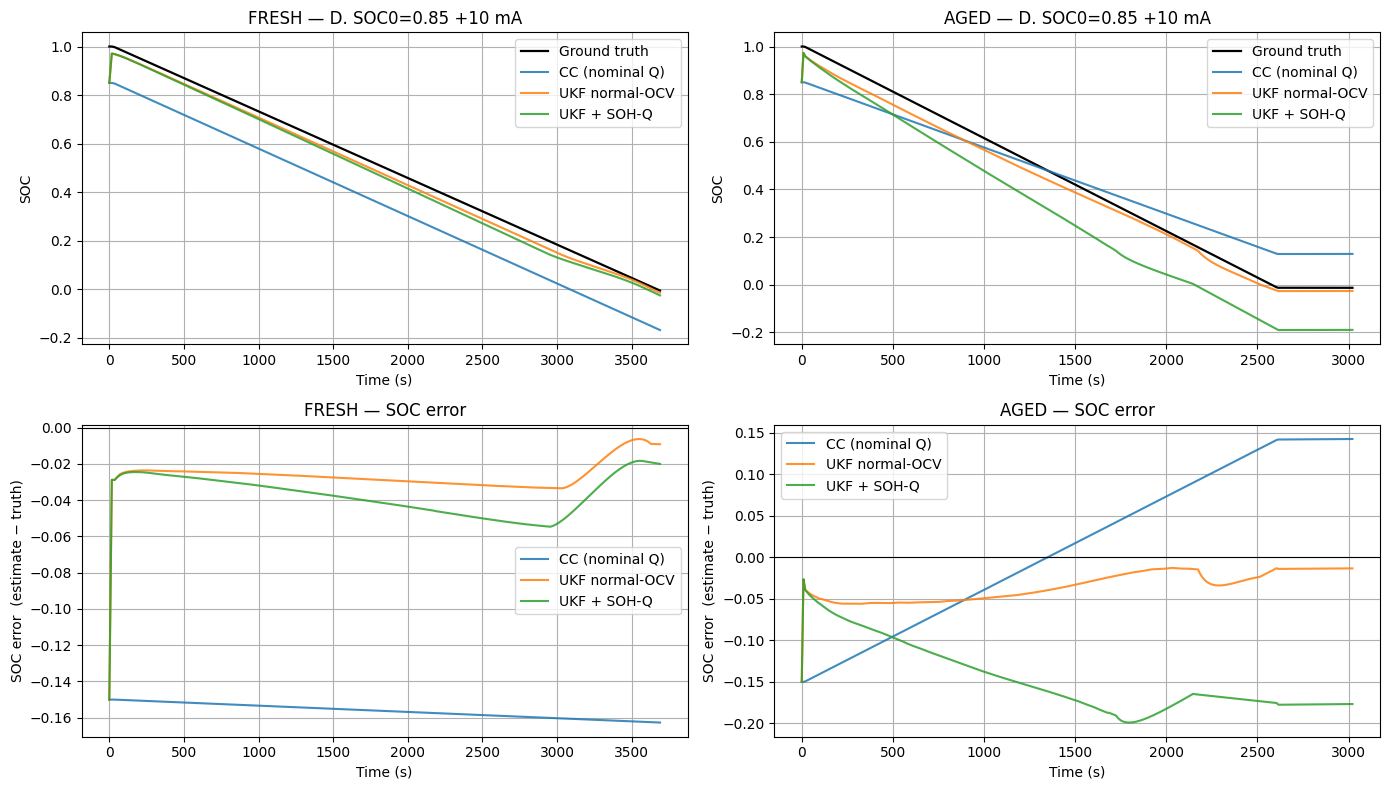

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sc = 'D. SOC0=0.85 +10 mA'
for col, (res, tag) in enumerate([(res_fresh, 'FRESH'), (res_aged, 'AGED')]):
    ests = res['scenarios'][sc]
    plot_soc_comparison(res['t'], res['truth'], *ests.values(), labels=list(ests.keys()),
                        title=f'{tag} — {sc}', ax=axes[0, col])
    plot_soc_error(res['t'], res['truth'], *ests.values(), labels=list(ests.keys()),
                   title=f'{tag} — SOC error', ax=axes[1, col])
plt.tight_layout(); plt.show()

### Cross-cycle scan + overall ranking

Scenario A (best-case) isolates the **aging** effect: open-loop CC drifts up as capacity fades,
while the UKF stays low and flat. The grand-mean over **all four scenarios × scanned cycles**
gives a single robustness score per estimator.

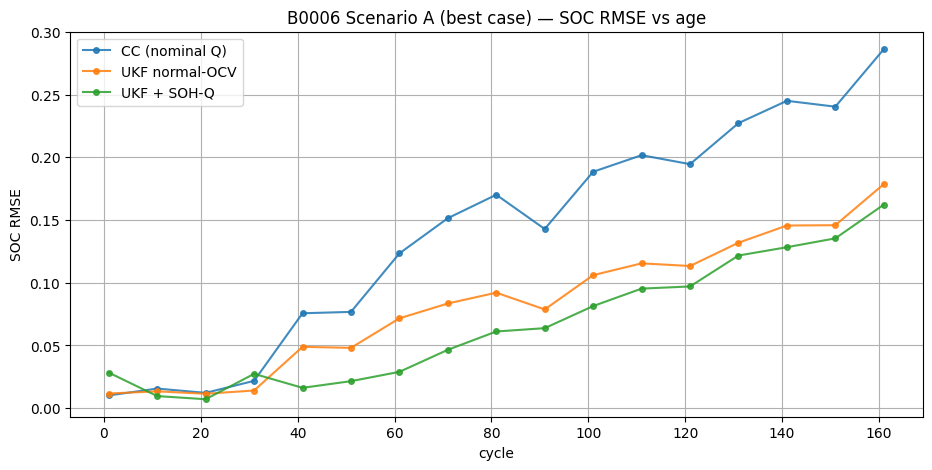

OVERALL robustness — mean SOC RMSE over all 4 scenarios x scanned cycles:
  CC (nominal Q)             0.1985   (median 0.1671)
  UKF normal-OCV             0.0718   (median 0.0643)
  UKF + SOH-Q                0.0959   (median 0.0758)


In [10]:
scan = list(range(1, len(disc_val) + 1, 10))
rmse_A = {e: [] for e in ESTIMATORS}      # scenario A, for the vs-age plot
grand  = {e: [] for e in ESTIMATORS}      # all scenarios, for the ranking
for c in scan:
    r = run_estimators(VAL_BAT, c)
    for e in ESTIMATORS:
        rmse_A[e].append(rmse(r['truth'], r['scenarios']['A. Best case'][e]))
        for sc in r['scenarios']:
            grand[e].append(rmse(r['truth'], r['scenarios'][sc][e]))

fig, ax = plt.subplots(figsize=(11, 5))
for e in ESTIMATORS:
    ax.plot(scan, rmse_A[e], '-o', ms=4, alpha=0.85, label=e)
ax.set_xlabel('cycle'); ax.set_ylabel('SOC RMSE')
ax.set_title(f'{VAL_BAT} Scenario A (best case) — SOC RMSE vs age'); ax.legend(); ax.grid(True)
plt.show()

print('OVERALL robustness — mean SOC RMSE over all 4 scenarios x scanned cycles:')
for e in ESTIMATORS:
    print(f'  {e:<26} {np.mean(grand[e]):.4f}   (median {np.median(grand[e]):.4f})')

## 8. Conclusions & ESP notes

**What the numbers say (above).**
- **A UKF with one static OCV cuts SOC RMSE ~3× vs open-loop Coulomb counting** (grand-mean
  ≈0.072 vs ≈0.199) — the core win, across the whole life of the cell and across wrong-SOC0 /
  current-bias scenarios.
- **SOH is recoverable online** from a 15-minute partial-discharge window (§2), val RMSE ≈ 0.048
  (robust Theil–Sen, smoothed health curve). This is the system's **SOH/health output**.
- **Feeding SOH→Q back into the SOC filter does *not* help on average** (≈0.096 vs ≈0.072): the
  OCV measurement already absorbs capacity fade, so the extra *estimated* Q mostly injects noise
  and hurts under current bias. It helps only in clean conditions. **So keep SOC and SOH
  decoupled** — UKF (nominal Q) for SOC, partial-window for SOH.
- Per §5 the per-cycle R/C fit is statistically unidentifiable, so the filter uses fixed priors.
  This is *why* the old 2-D SOH×OCV table and the LSTM didn't help: the data doesn't support them.

**Is the data enough?**  Yes for OCV/SOC and SOH (capacity); **no** for splitting R1/C1.
Identifying the RC branch would need pulse/HPPC excitation and/or ≥1 Hz logging.

**Ship this:** SOC = `UKF + normal static OCV + fixed priors + nominal Q`; SOH = `partial-window
dV → SOH`. Simplest, robust, fully online, embedded-cheap.

**ESP deployment footprint.**
- OCV: the two exported `SOC_GRID` / `OCV_GRID` arrays + a `lerp` (see §3 firmware block).
- SOH: one `dV` over a 15-min window + the two scalars `SOH_A, SOH_B` → SOH (→ optional Q).
- Filter: 2-state UKF — fixed 2×2 matrices, one 2×2 Cholesky per step, no heap, no ML runtime.
- Params: three constants `R0_PRIOR, R1_PRIOR, C1_PRIOR`; one tuning scalar `R_MEAS`.

**Deferred (separate notebook):** LSTM parameter prediction and the 2-D SOH×SOC OCV table —
they add complexity without robust accuracy gains on this dataset.